### Exploratory Data Analysis – Key Insights

- The dataset contains 103024 rows and 21 columns after removing non-informative features.
- No duplicate Booking_IDs were found, confirming one-to-one mapping between records and bookings.
- Booking_Value exhibits a right-skewed distribution, indicating that the majority of bookings are low to mid-value, with a small number of high-value transactions.
- Payment_Method analysis shows dominance of specific payment modes, reflecting customer payment preferences.
- The Date column was converted to date time format to enable date and trend analysis.
- Overall, the dataset is clean, consistent, and ready for further exploratory analysis or predictive modeling.


In [ ]:
# 1) Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# 2) Load the dataset
df = pd.read_csv('/content/Bookings.csv')

In [ ]:
# 3) i) Preview the dataset
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
0,2024-07-26 14:00:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,...,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,#NAME?,NaN
1,2024-07-25 22:20:00,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,...,NaN,No,NaN,158,Cash,13,4.1,4.0,#NAME?,NaN
2,2024-07-30 19:59:00,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,...,NaN,No,NaN,386,UPI,40,4.2,4.8,#NAME?,NaN
3,2024-07-22 3:15:00,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,...,NaN,NaN,NaN,384,NaN,0,NaN,NaN,#NAME?,NaN
4,2024-07-02 9:02:00,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,...,NaN,No,NaN,822,Credit Card,45,4.0,3.0,#NAME?,NaN


In [ ]:
# 4) ii) Preview the dataset
df.tail()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,...,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images,Unnamed: 20
103019,2024-07-31 9:06:00,09:06:00,CNR9488489435,Success,CID371654,Prime Plus,Richmond Town,Varthur,245.0,35.0,...,NaN,No,NaN,111,Cash,41,3.6,3.8,#NAME?,NaN
103020,2024-07-31 15:12:00,15:12:00,CNR3151743100,Success,CID334158,Auto,Vijayanagar,Richmond Town,84.0,145.0,...,NaN,No,NaN,1097,UPI,17,4.3,3.3,#NAME?,NaN
103021,2024-07-31 13:59:00,13:59:00,CNR1286151233,Success,CID113188,Prime SUV,Bannerghatta Road,JP Nagar,35.0,75.0,...,NaN,No,NaN,2201,Cash,37,3.6,3.2,#NAME?,NaN
103022,2024-07-31 14:56:00,14:56:00,CNR2027162035,Success,CID118301,eBike,Indiranagar,Magadi Road,210.0,140.0,...,NaN,No,NaN,267,UPI,47,3.4,3.1,#NAME?,NaN
103023,2024-07-31 13:57:00,13:57:00,CNR9770709721,Success,CID217959,Auto,Ulsoor,Hennur,175.0,125.0,...,NaN,No,NaN,462,UPI,3,4.8,4.4,#NAME?,NaN


In [ ]:
# 5) Check the columns
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating',
       'Vehicle Images', 'Unnamed: 20'],
      dtype='object')

In [ ]:
# 6) Check for Missing Values Explicitly
df.isnull().sum()

,0
Date,0
Time,0
Booking_ID,0
Booking_Status,0
Customer_ID,0
Vehicle_Type,0
Pickup_Location,0
Drop_Location,0
V_TAT,39057
C_TAT,39057


###Shape

- The dataset contains 42,345 rows and 19 columns after removing non-informative features.


In [ ]:
# 7) Check for shape value
df.shape

(103024, 21)

In [ ]:
# 8) i) Drop Temporary Column (Cleanup)
df.drop(columns=['Unnamed: 20'], inplace=True)


In [ ]:
# 8) ii) Drop Temporary Column (Cleanup)
df.drop(columns=['Vehicle Images'], inplace=True)


In [ ]:
# 9) Check the column after removing columns
df.columns

Index(['Date', 'Time', 'Booking_ID', 'Booking_Status', 'Customer_ID',
       'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT',
       'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver',
       'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value',
       'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating'],
      dtype='object')

In [ ]:
# 10) Final dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Date                        103024 non-null  object 
 1   Time                        103024 non-null  object 
 2   Booking_ID                  103024 non-null  object 
 3   Booking_Status              103024 non-null  object 
 4   Customer_ID                 103024 non-null  object 
 5   Vehicle_Type                103024 non-null  object 
 6   Pickup_Location             103024 non-null  object 
 7   Drop_Location               103024 non-null  object 
 8   V_TAT                       63967 non-null   float64
 9   C_TAT                       63967 non-null   float64
 10  Canceled_Rides_by_Customer  10499 non-null   object 
 11  Canceled_Rides_by_Driver    18434 non-null   object 
 12  Incomplete_Rides            63967 non-null   object 
 13  Incomplete_Rid

In [ ]:
# 11) Describe the numerical column
df.describe()

,V_TAT,C_TAT,Booking_Value,Ride_Distance,Driver_Ratings,Customer_Rating
count,63967.000000,63967.000000,103024.000000,103024.000000,63967.000000,63967.000000
mean,170.876952,84.873372,548.751883,14.189927,3.997457,3.998313
std,80.803640,36.005100,536.541221,15.776270,0.576834,0.578957
min,35.000000,25.000000,100.000000,0.000000,3.000000,3.000000
25%,98.000000,55.000000,242.000000,0.000000,3.500000,3.500000
50%,168.000000,85.000000,386.000000,8.000000,4.000000,4.000000
75%,238.000000,115.000000,621.000000,26.000000,4.500000,4.500000
max,308.000000,145.000000,2999.000000,49.000000,5.000000,5.000000


In [ ]:
# 12) Duplicated values
df['Booking_ID'].duplicated().sum()

np.int64(0)

In [ ]:
# 13) Convert date to datetime
df['Date'] = pd.to_datetime(df['Date'])


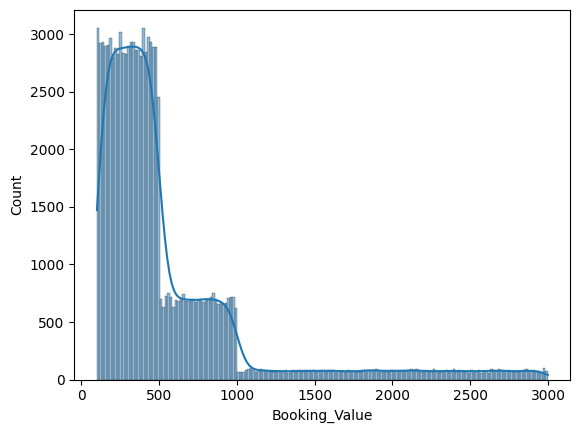

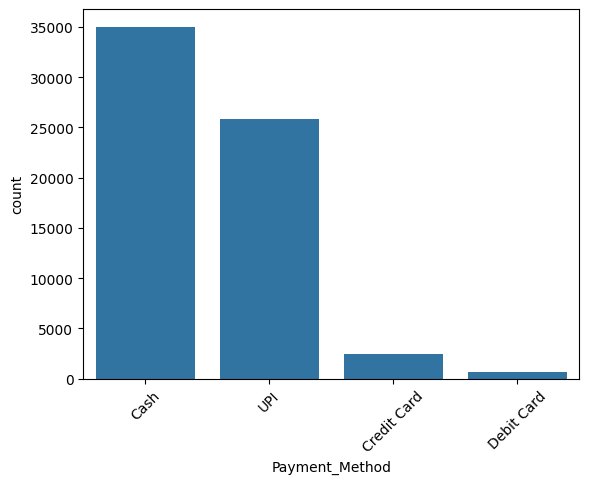

In [ ]:
# 14) Visualising the data
import seaborn as sns

sns.histplot(df['Booking_Value'], kde=True)
plt.show()

sns.countplot(x='Payment_Method', data=df)
plt.xticks(rotation=45)
plt.show()


### Initial Observations

- The dataset contains 103024 rows and 21 columns after removing non-informative features.
- Missing values are present in selected columns and will be handled before modeling.
- Numerical variables such as Booking_Value and Ride_Distance show variability across bookings.
- The dataset is now prepared for visualization and deeper analysis.
